# Intrinsic Timescales (INT) Computation via Impulse Stimulation Method

## Overview

This notebook implements the first method described in **Deco et al. (2021)** for computing intrinsic timescales in brain network models. We will analyze the temporal decay dynamics of regional activity following impulse stimulation to characterize the intrinsic timescales of each brain region in our fitted models.

## Background and Motivation

Intrinsic timescales reflect the duration over which neural activity remains correlated with itself, providing insights into the hierarchical organization of brain dynamics. Different brain regions exhibit distinct timescales that are thought to reflect their functional roles - from fast sensory processing to slow integrative functions.

## Methodology

### Theoretical Framework

Following **Chaudhuri et al. (2015)** and **Deco et al. (2021)**, we examine activity timescales by analyzing the rate at which regional activity decays following impulse stimulation. This approach provides a direct measure of how long neural activity persists in each brain region after a brief perturbation.

### Stimulation Protocol

- **Pre-stimulation phase**: 3000 ms under spontaneous conditions to eliminate transients
- **Stimulation phase**: 1000 ms impulse stimulation (from 3000ms to 4000ms)
- **Post-stimulation phase**: 3000 ms relaxation period (from 4000ms to 7000ms) with external stimulation reset to zero
- **Target stimulation site**: Lateral occipital region
- **Analysis scope**: All brain regions (as targets for decay analysis)
- **Repetitions**: 1000 simulations for statistical robustness
### Mathematical Model

The temporal decay of regional firing rates follows an exponential decay function:

$$r^{E}_i(t) = A × exp(-D × t) + B$$


Where:
- $r^{E}_i(t)$: Firing rate (Hz) of region i at time t after stimulation
- `t`: Time after stimulation (seconds)
- `D`: **Decay rate parameter** (our primary measure of intrinsic timescale)
- `A`: Scaling constant (amplitude of decay)
- `B`: Offset parameter (baseline firing rate)

### Key Analysis Steps

1. **Simulation Setup and Stimulation Phase**
   - Run whole-brain model for 3000 ms under spontaneous conditions (eliminate transients)
   - Apply 1000 ms impulse stimulation to lateral occipital region (3000-4000 ms)
   - Allow 3000 ms relaxation period with stimulation reset to zero (4000-7000 ms)
   - Record the response across all brain regions throughout the entire 7000 ms simulation

2. **Recording Phase**
   - Monitor firing rates in all brain regions following stimulation
   - Record temporal evolution of activity for sufficient duration
   - Repeat for 1000 independent simulations

3. **Data Processing**
   - Average firing rate trajectories across 1000 simulations
   - Extract post-stimulation time series (4000-7000 ms period) for each brain region
   - Focus analysis on the decay dynamics during the relaxation phase
   - Prepare data for exponential curve fitting
   
4. **Curve Fitting**
   - Fit exponential decay model using **nonlinear least squares**
   - Extract decay rate parameter `D` for each brain region
   - Compute **intrinsic timescale** as `τ = 1/D` (in seconds)

5. **Analysis and Visualization**
   - Compare timescales across brain regions
   - Examine relationship with T1w/T2w hierarchy
   - Validate fits and assess goodness-of-fit metrics

## Hypotheses

From **Deco et al. (2021)** 
- A clear trend is evident for rapid decay in visual regions and more prolonged responses in prefrontal areas
- A significant positive correlation between regional decay values and an independent measure of cortical hierarchy, T1w:T2w


## Expected Outputs

- **Regional decay curves**: Visualization of firing rate decay for each brain region
- **Fitted parameters**: Decay rates (D), scaling factors (A), and offsets (B) for all regions
- **Intrinsic timescales**: Timescale values (τ = 1/D) for hierarchical analysis
- **Quality metrics**: R-squared values and residual analysis for fit validation
- **Comparative analysis**: Regional differences and potential functional implications

## Implementation Strategy

The notebook will proceed through the following phases:

1. **Setup and Configuration**: Load fitted models, define stimulation parameters
2. **Simulation Loop**: Run 1000 stimulation trials with data collection
3. **Data Aggregation**: Average responses and prepare for curve fitting
4. **Exponential Fitting**: Apply nonlinear least squares to extract timescales
5. **Results Analysis**: Visualization and interpretation of regional timescales

## References

1. **Deco, G., Kringelbach, M. L., Arnatkeviciute, A., Oldham, S., Sabaroedin, K., Rogasch, N. C., Aquino, K. M., & Fornito, A. (2021)**. Dynamical consequences of regional heterogeneity in the brain's transcriptional landscape. *Science Advances*, *7*(29), eabf4752. [https://doi.org/10.1126/sciadv.abf4752](https://doi.org/10.1126/sciadv.abf4752)

2. **Chaudhuri, R., Knoblauch, K., Gariel, M.-A., Kennedy, H., & Wang, X.-J. (2015)**. A Large-Scale Circuit Mechanism for Hierarchical Dynamical Processing in the Primate Cortex. *Neuron*, *88*(2), 419–431. [https://doi.org/10.1016/j.neuron.2015.09.008](https://doi.org/10.1016/j.neuron.2015.09.008)

---

**Note**: This implementation focuses on the first timescale measurement method from Deco et al. (2021). The second method (autocorrelation-based) may be implemented in a separate notebook for comparison.


## Simulation Setup

In [1]:
# Imports 
import numpy as np
from scipy.stats import pearsonr
from hbnm.model.utils import subdiag, fisher_z, linearize_map
import matplotlib.pyplot as plt
from hbnm.io import Data
import os
from hbnm.bnm import Bnm
import glob
import nibabel as nib  # For loading custom .pscalar.nii maps

In [2]:
# Set up data loader
input_dir = "/home/frank/HBNM/data/"
output_dir = "/home/frank/HBNM/outputs/"
data = Data(input_dir, output_dir)  

# Load HCP SC and Empirical FC Matrices
sc, hmap, fc_obj = data.load_demirtas_neuron_2019_data() # Loads Myelin HMAP by default
# Compute number of cortical regions
nc = sc.shape[0]
print(f"Number of cortical regions: {nc}")


Number of cortical regions: 180


**Load the model parameters and compute Bayesian Model Average (BMA) for best parameter combination**

In [3]:
# "/home/frank/HBNM/data/maps/dopamine_avg.pscalar.nii"
# "/home/frank/HBNM/data/maps/dopamine_d1like_avg.pscalar.nii"
# "/home/frank/HBNM/data/maps/dopamine_d2like_avg.pscalar.nii"
# "/home/frank/HBNM/data/maps/gaba_a_avg.pscalar.nii"
# "/home/frank/HBNM/data/maps/muscarinic_avg.pscalar.nii"
# "/home/frank/HBNM/data/maps/nicotinic_avg.pscalar.nii"
# "/home/frank/HBNM/data/maps/NMDA_avg.pscalar.nii"
# "/home/frank/HBNM/data/maps/norepinephrine_avg.pscalar.nii"
# "/home/frank/HBNM/data/maps/serotonin_avg.pscalar.nii"

In [ ]:
# ==========================================
# MODEL PARAMETER CONFIGURATION
# ==========================================

MODEL_CONFIG = {
    'model_folder': 'NMDA_AVG',           # Folder containing iteration files
    'file_pattern': 'iteration_*.hdf5',     # Pattern for iteration files
    'use_latest': True,                     # Auto-detect latest iteration
    'fallback_iteration': 20,               # Fallback if auto-detection fails
    
    # Hierarchical map configuration (for heterogeneous models only)
    'map_config': {
        'use_default_map': False,            # Use the pre-loaded myelin map (hmap)
        'custom_map_path': '/home/frank/HBNM/data/maps/NMDA_avg.pscalar.nii',            # Path to custom map file (.pscalar.nii)
        'invert_flags': [False],            # Array of True/False for each map dimension
                                           # True = invert map values for excitatory dynamics
        
        # Examples for custom maps:
        # 'use_default_map': False,
        # 'custom_map_path': '/path/to/custom_map.pscalar.nii',
        # 'invert_flags': [True],           # For single map that needs inversion
        # 'invert_flags': [True, False],    # For multiple maps with different inversion needs
    }
}

# ==========================================
# AUTO-DETECT LATEST ITERATION LOGIC
# ==========================================

def find_latest_iteration(folder_path, pattern):
    """Find the latest iteration file in the specified folder."""
    search_path = os.path.join(data.output_dir, folder_path, pattern)
    iteration_files = glob.glob(search_path)
    
    if not iteration_files:
        return None
    
    # Extract iteration numbers and find the maximum
    iteration_numbers = []
    for file_path in iteration_files:
        filename = os.path.basename(file_path)
        try:
            # Extract number from "iteration_XX.hdf5"
            iter_num = int(filename.split('_')[1].split('.')[0])
            iteration_numbers.append((iter_num, file_path))
        except (ValueError, IndexError):
            continue
    
    if iteration_numbers:
        latest_iter, latest_file = max(iteration_numbers, key=lambda x: x[0])
        relative_path = os.path.relpath(latest_file, data.output_dir)
        return latest_iter, relative_path
    
    return None

# Determine which file to load
if MODEL_CONFIG['use_latest']:
    result = find_latest_iteration(MODEL_CONFIG['model_folder'], MODEL_CONFIG['file_pattern'])
    if result:
        latest_iter, file_path = result
        print(f"✓ Auto-detected latest iteration: {latest_iter}")
    else:
        file_path = f"{MODEL_CONFIG['model_folder']}/iteration_{MODEL_CONFIG['fallback_iteration']}.hdf5"
        latest_iter = MODEL_CONFIG['fallback_iteration']
        print(f"⚠ Auto-detection failed, using fallback: iteration {latest_iter}")
else:
    file_path = f"{MODEL_CONFIG['model_folder']}/iteration_{MODEL_CONFIG['fallback_iteration']}.hdf5"
    latest_iter = MODEL_CONFIG['fallback_iteration']
    print(f"✓ Using specified iteration: {latest_iter}")

# ==========================================
# BAYESIAN MODEL AVERAGING LOGIC
# ==========================================

# Load model parameters
print(f"Loading: {file_path}")
fin_model = data.load(file_path, from_output=True)

# Extract data and compute BMA
theta_samples = fin_model['theta'][:]
weights = fin_model['weights'][:]
normalized_weights = weights / np.sum(weights)

# Compute weighted average (BMA)
theta_bma = np.sum(theta_samples * normalized_weights[np.newaxis, :], axis=1)

# For comparison: simple posterior mean
theta_mean = np.mean(theta_samples, axis=1)

fin_model.close()

# ==========================================
# PARAMETER STRUCTURE DETECTION & FORMATTING
# ==========================================

n_params = theta_samples.shape[0]

# Auto-detect model type and structure parameters
if n_params == 3:
    # Homogeneous model (3 parameters)
    model_type = "homogeneous"
    model_params = {
        'w_EI': theta_bma[0],
        'w_EE': theta_bma[1], 
        'G': theta_bma[2]
    }
    model_params_mean = {
        'w_EI': theta_mean[0],
        'w_EE': theta_mean[1],
        'G': theta_mean[2]
    }
    
elif n_params == 5:
    # Heterogeneous model (5 parameters: baseline + scaling for w_EI, w_EE)
    model_type = "heterogeneous"
    model_params = {
        'w_EI': (theta_bma[0], theta_bma[1]),  # (baseline, scaling)
        'w_EE': (theta_bma[2], theta_bma[3]),  # (baseline, scaling)
        'G': theta_bma[4]
    }
    model_params_mean = {
        'w_EI': (theta_mean[0], theta_mean[1]),
        'w_EE': (theta_mean[2], theta_mean[3]),
        'G': theta_mean[4]
    }
    
else:
    raise ValueError(f"Unsupported parameter count: {n_params}. Expected 3 (homogeneous) or 5 (heterogeneous)")

# ==========================================
# MAP PROCESSING (FOR HETEROGENEOUS MODELS)
# ==========================================

def load_custom_map(map_path):
    """Load and process custom map from .pscalar.nii file."""
    import nibabel as nib
    from hbnm.model.utils import linearize_map
    
    try:
        # Load the .pscalar.nii file
        img = nib.load(map_path)
        map_data = img.get_fdata().squeeze()  # Remove singleton dimensions
        
        # Apply linearization
        linearized_map = linearize_map(map_data)
        
        return linearized_map
    except Exception as e:
        raise ValueError(f"Failed to load custom map from {map_path}: {str(e)}")

# Process maps based on model type and configuration
if model_type == "homogeneous":
    # Homogeneous models don't use maps
    processed_maps = None
    map_invert_flags = None
    print("  Maps: Not applicable (homogeneous model)")
    
elif model_type == "heterogeneous":
    # Heterogeneous models require maps
    map_config = MODEL_CONFIG['map_config']
    
    if map_config['use_default_map']:
        # Use the pre-loaded myelin map (hmap)
        processed_maps = hmap  # Already linearized in the data loader
        map_invert_flags = map_config['invert_flags']
        print(f"  Maps: Using default myelin map | Invert flags: {map_invert_flags}")
        
    else:
        # Load custom map
        if map_config['custom_map_path'] is None:
            raise ValueError("Custom map path must be specified when use_default_map=False")
        
        custom_map_path = map_config['custom_map_path']
        print(f"  Maps: Loading custom map from {custom_map_path}")
        
        # Load and process the custom map
        processed_maps = load_custom_map(custom_map_path)
        map_invert_flags = map_config['invert_flags']
        
        print(f"  Maps: Custom map loaded and linearized | Shape: {processed_maps.shape}")
        print(f"  Maps: Invert flags: {map_invert_flags}")
        
        # Validate map dimensions
        if len(processed_maps.shape) == 1:
            # Single map, ensure invert_flags has correct length
            if len(map_invert_flags) != 1:
                raise ValueError(f"For single map, invert_flags should have length 1, got {len(map_invert_flags)}")
        else:
            # Multiple maps, check dimensions
            n_maps = processed_maps.shape[0] if processed_maps.ndim == 2 else 1
            if len(map_invert_flags) != n_maps:
                raise ValueError(f"Number of invert flags ({len(map_invert_flags)}) must match number of maps ({n_maps})")

# Store processed maps for later use
model_maps = processed_maps
model_map_invert_flags = map_invert_flags

# ==========================================
# SUMMARY OUTPUT
# ==========================================

print(f"✓ {model_type.title()} model parameters loaded from iteration {latest_iter}")
print(f"  Samples: {theta_samples.shape[1]} | Parameters: {n_params} ({model_type})")

if model_type == "homogeneous":
    print(f"  BMA estimates: w_EI={model_params['w_EI']:.4f}, w_EE={model_params['w_EE']:.4f}, G={model_params['G']:.4f}")
    print(f"  vs Mean: w_EI={model_params_mean['w_EI']:.4f}, w_EE={model_params_mean['w_EE']:.4f}, G={model_params_mean['G']:.4f}")
    
elif model_type == "heterogeneous":
    print(f"  BMA estimates:")
    print(f"    w_EI: ({model_params['w_EI'][0]:.4f}, {model_params['w_EI'][1]:.4f}) [baseline, scaling]")
    print(f"    w_EE: ({model_params['w_EE'][0]:.4f}, {model_params['w_EE'][1]:.4f}) [baseline, scaling]")
    print(f"    G: {model_params['G']:.4f}")
    print(f"  vs Mean:")
    print(f"    w_EI: ({model_params_mean['w_EI'][0]:.4f}, {model_params_mean['w_EI'][1]:.4f}) [baseline, scaling]")
    print(f"    w_EE: ({model_params_mean['w_EE'][0]:.4f}, {model_params_mean['w_EE'][1]:.4f}) [baseline, scaling]")
    print(f"    G: {model_params_mean['G']:.4f}")

✓ Auto-detected latest iteration: 41
Loading: NMDA_AVG/iteration_41.hdf5
  Maps: Loading custom map from /home/frank/HBNM/data/maps/NMDA_avg.pscalar.nii
  Maps: Custom map loaded and linearized | Shape: (180,)
  Maps: Invert flags: [False]
✓ Heterogeneous model parameters loaded from iteration 41
  Samples: 300 | Parameters: 5 (heterogeneous)
  BMA estimates:
    w_EI: (0.2394, 0.9560) [baseline, scaling]
    w_EE: (0.4622, 2.2340) [baseline, scaling]
    G: 0.8774
  vs Mean:
    w_EI: (0.2608, 1.0353) [baseline, scaling]
    w_EE: (0.4823, 2.5901) [baseline, scaling]
    G: 0.9644


In [5]:
# ==========================================
# STIMULATION CONFIGURATION
# ==========================================

# Simulation timing (Deco et al. protocol)
CONFIG = {
    'total_time': 7.0,          # Total simulation time (s): 3s pre + 1s stim + 3s post
    'dt': 0.0001,               # Time step (s): 0.1ms resolution
    'n_save': 10,               # Save every Nth step (effective 1ms sampling)
    
    # Stimulation parameters
    'stim_region_idx': 0,       # Target region index (lateral occipital)
    'stim_start_time': 3.0,     # Stimulation start (s)
    'stim_duration': 1.0,       # Stimulation duration (s)
    'stim_amplitude': 0.2,      # Stimulation strength (nA)
}

# ==========================================
# STIMULATION SETUP LOGIC
# ==========================================

# Compute derived parameters
n_steps = int(CONFIG['total_time'] / CONFIG['dt']) + 1
time_points = np.arange(0, CONFIG['total_time'] + CONFIG['dt'], 
                       CONFIG['dt'] * CONFIG['n_save'])

# Create stimulation array
stim_array = np.zeros((n_steps, nc))

# Apply stimulation pulse
i_start = int(CONFIG['stim_start_time'] / CONFIG['dt'])
i_end = i_start + int(CONFIG['stim_duration'] / CONFIG['dt'])
stim_array[i_start:i_end, CONFIG['stim_region_idx']] = CONFIG['stim_amplitude']

# ==========================================
# SUMMARY OUTPUT
# ==========================================

print(f"✓ Stimulation configured:")
print(f"  Duration: {CONFIG['total_time']}s | Sampling: {1/(CONFIG['dt']*CONFIG['n_save']):.0f}Hz")
print(f"  Target: Region {CONFIG['stim_region_idx']} | Period: {CONFIG['stim_start_time']}-{CONFIG['stim_start_time']+CONFIG['stim_duration']}s")
print(f"  Array shape: {stim_array.shape} | Amplitude: {CONFIG['stim_amplitude']}nA")

✓ Stimulation configured:
  Duration: 7.0s | Sampling: 1000Hz
  Target: Region 0 | Period: 3.0-4.0s
  Array shape: (70001, 180) | Amplitude: 0.2nA


## Stimulation Recording

In [6]:
# Parallelized Recording Phase (REORGANIZED)
print("=== PARALLELIZED RECORDING ===")

import multiprocessing as mp
from multiprocessing import Pool
import numpy as np
import time
from copy import deepcopy

# ==========================================
# CONFIGURATION SECTION
# ==========================================

# Simulation parameters
n_trials = 1000                            # Number of simulation trials to run
max_cores = 12                           # Maximum number of cores to use
progress_update_freq = 50               # Show progress every N trials

# Derived parameters (do not modify unless needed)
n_cores = min(max_cores, mp.cpu_count() - 1)  # Use all but 1 core, max specified
print(f"Using {n_cores} parallel processes for {n_trials} trials")

# ==========================================
# FUNCTION DEFINITIONS
# ==========================================

def run_single_trial(args):
    """Run a single trial and return the firing rate time series
    
    Supports both homogeneous and heterogeneous models
    """
    trial_num, sim_params = args
    
    # Import inside function for multiprocessing
    from hbnm.bnm import Bnm
    import numpy as np
    
    # Unpack parameters
    sc, model_params, model_type, total_time, dt, n_save, stim_array, model_maps, map_invert_flags = sim_params
    
    # Create model based on type
    if model_type == "homogeneous":
        trial_model = Bnm(sc)
        trial_model.set('w_EI', model_params['w_EI'])
        trial_model.set('w_EE', model_params['w_EE'])
        trial_model.set('G', model_params['G'])
        
    elif model_type == "heterogeneous":
        trial_model = Bnm(sc, maps=model_maps, map_invert_flags=map_invert_flags)
        trial_model.set('w_EI', model_params['w_EI'])  # (baseline, scaling) tuple
        trial_model.set('w_EE', model_params['w_EE'])  # (baseline, scaling) tuple
        trial_model.set('G', model_params['G'])
        
    else:
        raise ValueError(f"Unsupported model type: {model_type}. Only 'homogeneous' or 'heterogeneous' are supported.")
    
    # Run simulation
    trial_model.dmf.integrate(
        t=total_time,
        dt=dt,
        n_save=n_save,
        stimulation=stim_array,
        delays=False,
        include_BOLD=True,
        from_fixed=True,
        sim_seed=trial_num
    )
    
    # Extract and return results
    r_E_trial = trial_model.dmf.sim.time_series('r_E')
    return r_E_trial

# ==========================================
# EXECUTION SECTION
# ==========================================

# Use the already detected model type and parameters from previous cell
print(f"Using {model_type} model:")
if model_type == "homogeneous":
    print(f"  w_EI={model_params['w_EI']:.3f}, w_EE={model_params['w_EE']:.3f}, G={model_params['G']:.3f}")
elif model_type == "heterogeneous":
    print(f"  w_EI=({model_params['w_EI'][0]:.3f}, {model_params['w_EI'][1]:.3f}), w_EE=({model_params['w_EE'][0]:.3f}, {model_params['w_EE'][1]:.3f}), G={model_params['G']:.3f}")

# Prepare arguments for each trial
sim_params = (sc, model_params, model_type, CONFIG['total_time'], CONFIG['dt'], CONFIG['n_save'], stim_array, model_maps, model_map_invert_flags)
trial_args = [(trial, sim_params) for trial in range(n_trials)]

# Initialize storage for results
all_r_E_parallel = np.zeros((n_trials, nc, len(time_points)))

# Run parallel simulations
print(f"Starting {n_trials} {model_type} trials on {n_cores} cores...")
start_time = time.time()

with Pool(n_cores) as pool:
    results = []
    for i, result in enumerate(pool.imap(run_single_trial, trial_args)):
        all_r_E_parallel[i] = result
        
        # Progress update based on configuration
        if (i + 1) % progress_update_freq == 0:
            elapsed = time.time() - start_time
            rate = (i + 1) / elapsed
            eta = (n_trials - i - 1) / rate
            print(f"Completed {i+1}/{n_trials} trials - Rate: {rate:.1f} trials/s - ETA: {eta:.1f}s")

# ==========================================
# RESULTS AND SUMMARY
# ==========================================

total_time_parallel = time.time() - start_time

print(f"\n✓ Parallel {model_type} recording completed!")
print(f"Total time: {total_time_parallel:.1f}s ({total_time_parallel/60:.1f} minutes)")
print(f"Average time per trial: {total_time_parallel/n_trials:.3f}s")
print(f"Effective rate: {n_trials/total_time_parallel:.1f} trials/second")
print(f"Final data shape: {all_r_E_parallel.shape}")

# Sanity check
print(f"\nSanity check:")
print(f"Mean firing rate: {all_r_E_parallel.mean():.3f}Hz")
print(f"Std firing rate: {all_r_E_parallel.std():.3f}Hz")

=== PARALLELIZED RECORDING ===
Using 12 parallel processes for 1000 trials
Using heterogeneous model:
  w_EI=(0.239, 0.956), w_EE=(0.462, 2.234), G=0.877
Starting 1000 heterogeneous trials on 12 cores...
Completed 50/1000 trials - Rate: 1.8 trials/s - ETA: 517.1s
Completed 100/1000 trials - Rate: 2.0 trials/s - ETA: 443.5s
Completed 150/1000 trials - Rate: 2.1 trials/s - ETA: 404.3s
Completed 200/1000 trials - Rate: 2.1 trials/s - ETA: 373.3s
Completed 250/1000 trials - Rate: 2.2 trials/s - ETA: 345.8s
Completed 300/1000 trials - Rate: 2.2 trials/s - ETA: 320.8s
Completed 350/1000 trials - Rate: 2.2 trials/s - ETA: 296.4s
Completed 400/1000 trials - Rate: 2.2 trials/s - ETA: 272.0s
Completed 450/1000 trials - Rate: 2.2 trials/s - ETA: 248.4s
Completed 500/1000 trials - Rate: 2.2 trials/s - ETA: 225.7s
Completed 550/1000 trials - Rate: 2.2 trials/s - ETA: 202.8s
Completed 600/1000 trials - Rate: 2.2 trials/s - ETA: 179.9s
Completed 650/1000 trials - Rate: 2.2 trials/s - ETA: 157.4s
Comp

## Data Processing

=== DATA PROCESSING ===
Step 1: Averaging firing rate trajectories across trials...
Using parallel data: (1000, 180, 7001)
Mean firing rates shape: (180, 7001)
Standard error shape: (180, 7001)
Averaged across 1000 trials

Step 2: Extracting post-stimulation decay period...
Post-stimulation period: 4.0s to 7.0s
Time point indices: 4000 to 7000
Decay time vector shape: (3001,)
Decay time range: 4.000s to 7.000s
Relative time range: 0.000s to 3.000s
Decay firing rates shape: (180, 3001)

Step 3: Computing decay dynamics characteristics...
Baseline firing rates - Mean: 3.101Hz, Range: 3.082-3.178Hz
Peak stimulation response - Mean: 3.981Hz, Range: 3.107-88.140Hz
Initial post-stim - Mean: 3.489Hz, Range: 0.434-10.065Hz
Final post-stim - Mean: 4.556Hz, Range: 3.145-12.846Hz

Step 4: Preparing data for exponential curve fitting...
Data structure created with 14 fields
Ready for exponential fitting: 180 regions x 3001 time points

Step 5: Quick visualization of decay characteristics...


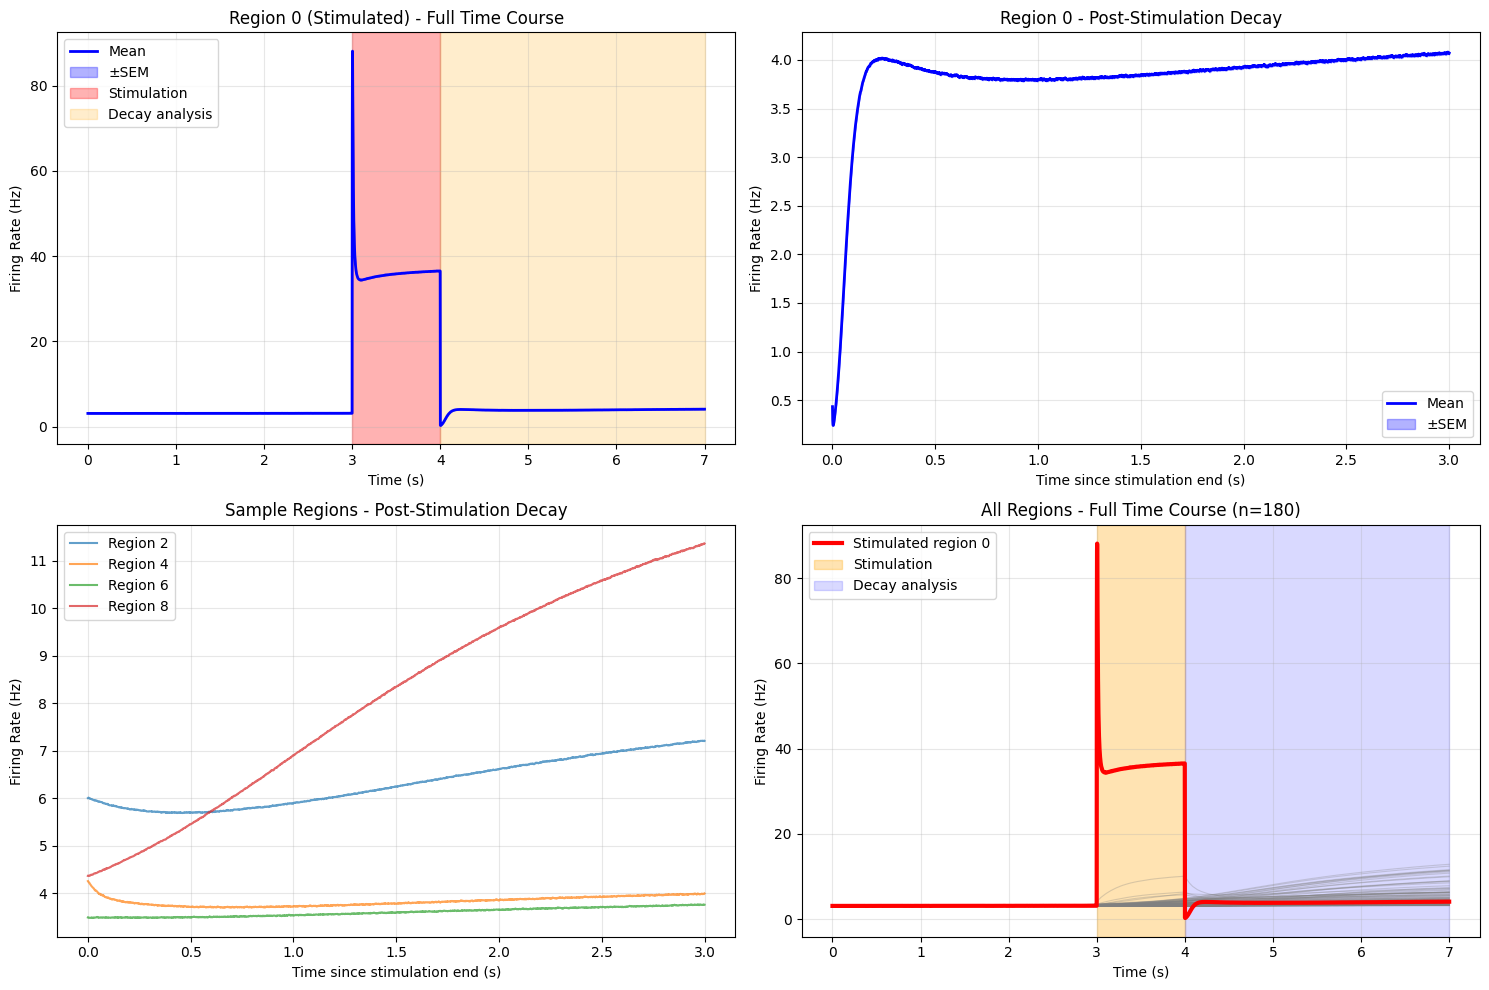


✓ Data processing completed!
Ready for exponential curve fitting on 180 brain regions
Decay data spans 3001 time points over 3.0 seconds


In [7]:
# Data Processing: Average trajectories and extract decay dynamics
print("=== DATA PROCESSING ===")

# Step 1: Average firing rate trajectories across all trials
print("Step 1: Averaging firing rate trajectories across trials...")

# Use the parallel data if available, otherwise fall back to sequential data
trial_data = all_r_E_parallel
n_trials_actual = all_r_E_parallel.shape[0]
print(f"Using parallel data: {trial_data.shape}")

# Compute mean and standard error across trials
mean_r_E = np.mean(trial_data, axis=0)  # Shape: (n_regions, n_timepoints)
std_r_E = np.std(trial_data, axis=0)    # Shape: (n_regions, n_timepoints) 
sem_r_E = std_r_E / np.sqrt(n_trials_actual)  # Standard error of mean

print(f"Mean firing rates shape: {mean_r_E.shape}")
print(f"Standard error shape: {sem_r_E.shape}")
print(f"Averaged across {n_trials_actual} trials")

# Step 2: Extract post-stimulation time series (4000-7000 ms period)
print("\nStep 2: Extracting post-stimulation decay period...")

# Time indices for post-stimulation phase (4000-7000 ms)
post_stim_start = 4.0  # seconds
post_stim_end = 7.0    # seconds

# Find corresponding time point indices
post_start_idx = int(post_stim_start / (CONFIG['dt'] * CONFIG['n_save']))
post_end_idx = int(post_stim_end / (CONFIG['dt'] * CONFIG['n_save']))

print(f"Post-stimulation period: {post_stim_start}s to {post_stim_end}s")
print(f"Time point indices: {post_start_idx} to {post_end_idx}")

# Extract post-stimulation time series
t_decay = time_points[post_start_idx:post_end_idx+1]  # Time vector for decay period
r_E_decay = mean_r_E[:, post_start_idx:post_end_idx+1]  # Decay trajectories
sem_decay = sem_r_E[:, post_start_idx:post_end_idx+1]  # Standard errors

# Create time vector relative to stimulation end (t=0 at stimulation end)
t_decay_relative = t_decay - post_stim_start  # Start from t=0 at 4000ms

print(f"Decay time vector shape: {t_decay.shape}")
print(f"Decay time range: {t_decay[0]:.3f}s to {t_decay[-1]:.3f}s")
print(f"Relative time range: {t_decay_relative[0]:.3f}s to {t_decay_relative[-1]:.3f}s")
print(f"Decay firing rates shape: {r_E_decay.shape}")

# Step 3: Focus analysis on decay dynamics - compute baseline and perturbation
print("\nStep 3: Computing decay dynamics characteristics...")

# Compute baseline firing rate (pre-stimulation: 0-3000ms)
baseline_start_idx = 0
baseline_end_idx = int(3.0 / (CONFIG['dt'] * CONFIG['n_save']))
baseline_r_E = np.mean(mean_r_E[:, baseline_start_idx:baseline_end_idx], axis=1)

# Compute peak response during stimulation (3000-4000ms)
stim_start_idx = int(3.0 / (CONFIG['dt'] * CONFIG['n_save']))
stim_end_idx = int(4.0 / (CONFIG['dt'] * CONFIG['n_save']))
peak_r_E = np.max(mean_r_E[:, stim_start_idx:stim_end_idx], axis=1)

# Compute initial post-stim firing rate (right after stimulation ends)
initial_post_r_E = r_E_decay[:, 0]

# Compute final post-stim firing rate (end of decay period)
final_post_r_E = r_E_decay[:, -1]

print(f"Baseline firing rates - Mean: {baseline_r_E.mean():.3f}Hz, Range: {baseline_r_E.min():.3f}-{baseline_r_E.max():.3f}Hz")
print(f"Peak stimulation response - Mean: {peak_r_E.mean():.3f}Hz, Range: {peak_r_E.min():.3f}-{peak_r_E.max():.3f}Hz") 
print(f"Initial post-stim - Mean: {initial_post_r_E.mean():.3f}Hz, Range: {initial_post_r_E.min():.3f}-{initial_post_r_E.max():.3f}Hz")
print(f"Final post-stim - Mean: {final_post_r_E.mean():.3f}Hz, Range: {final_post_r_E.min():.3f}-{final_post_r_E.max():.3f}Hz")

# Step 4: Prepare data for exponential curve fitting
print("\nStep 4: Preparing data for exponential curve fitting...")

# Store all processed data in organized structure
decay_data = {
    'time_points': time_points,           # Full time vector
    'time_decay': t_decay,                # Absolute time for decay period  
    'time_decay_rel': t_decay_relative,   # Relative time (t=0 at stim end)
    'mean_r_E_full': mean_r_E,           # Full mean trajectories
    'sem_r_E_full': sem_r_E,             # Full standard errors
    'r_E_decay': r_E_decay,              # Decay period trajectories
    'sem_decay': sem_decay,              # Decay period standard errors
    'baseline_r_E': baseline_r_E,        # Pre-stim baseline per region
    'peak_r_E': peak_r_E,                # Peak response per region
    'initial_post_r_E': initial_post_r_E, # Initial post-stim per region
    'final_post_r_E': final_post_r_E,    # Final post-stim per region
    'n_trials': n_trials_actual,         # Number of trials averaged
    'n_regions': mean_r_E.shape[0],      # Number of brain regions
    'stimulated_region': CONFIG['stim_region_idx']  # Which region was stimulated
}

print(f"Data structure created with {len(decay_data)} fields")
print(f"Ready for exponential fitting: {decay_data['n_regions']} regions x {len(t_decay_relative)} time points")

# Quick visualization of decay dynamics
print("\nStep 5: Quick visualization of decay characteristics...")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Full time course for stimulated region
ax = axes[0, 0]
stim_idx = CONFIG['stim_region_idx']
ax.plot(time_points, mean_r_E[stim_idx, :], 'b-', linewidth=2, label='Mean')
ax.fill_between(time_points, 
                mean_r_E[stim_idx, :] - sem_r_E[stim_idx, :],
                mean_r_E[stim_idx, :] + sem_r_E[stim_idx, :],
                alpha=0.3, color='blue', label='±SEM')
ax.axvspan(3.0, 4.0, alpha=0.3, color='red', label='Stimulation')
ax.axvspan(4.0, 7.0, alpha=0.2, color='orange', label='Decay analysis')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Firing Rate (Hz)')
ax.set_title(f'Region {stim_idx} (Stimulated) - Full Time Course')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Decay phase for stimulated region
ax = axes[0, 1]
ax.plot(t_decay_relative, r_E_decay[stim_idx, :], 'b-', linewidth=2, label='Mean')
ax.fill_between(t_decay_relative,
                r_E_decay[stim_idx, :] - sem_decay[stim_idx, :],
                r_E_decay[stim_idx, :] + sem_decay[stim_idx, :],
                alpha=0.3, color='blue', label='±SEM')
ax.set_xlabel('Time since stimulation end (s)')
ax.set_ylabel('Firing Rate (Hz)')
ax.set_title(f'Region {stim_idx} - Post-Stimulation Decay')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Decay phase for sample of other regions
ax = axes[1, 0]
sample_regions = [i for i in range(0, min(10, decay_data['n_regions']), 2) if i != stim_idx][:5]
for i, region_idx in enumerate(sample_regions):
    ax.plot(t_decay_relative, r_E_decay[region_idx, :], 
            alpha=0.7, linewidth=1.5, label=f'Region {region_idx}')
ax.set_xlabel('Time since stimulation end (s)')
ax.set_ylabel('Firing Rate (Hz)')
ax.set_title('Sample Regions - Post-Stimulation Decay')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 4: Full time course for all regions
ax = axes[1, 1]
# Plot all non-stimulated regions with low alpha
for region_idx in range(decay_data['n_regions']):
    if region_idx != stim_idx:
        ax.plot(time_points, mean_r_E[region_idx, :], 
                color='gray', alpha=0.3, linewidth=0.8)

# Plot stimulated region with emphasis
ax.plot(time_points, mean_r_E[stim_idx, :], 
        color='red', linewidth=3, label=f'Stimulated region {stim_idx}')
ax.fill_between(time_points, 
                mean_r_E[stim_idx, :] - sem_r_E[stim_idx, :],
                mean_r_E[stim_idx, :] + sem_r_E[stim_idx, :],
                alpha=0.2, color='red')

# Add stimulation and analysis periods
ax.axvspan(3.0, 4.0, alpha=0.3, color='orange', label='Stimulation')
ax.axvspan(4.0, 7.0, alpha=0.15, color='blue', label='Decay analysis')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Firing Rate (Hz)')
ax.set_title(f'All Regions - Full Time Course (n={decay_data["n_regions"]})')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✓ Data processing completed!")
print(f"Ready for exponential curve fitting on {decay_data['n_regions']} brain regions")
print(f"Decay data spans {len(t_decay_relative)} time points over {t_decay_relative[-1]:.1f} seconds")


## Exponential Curve Fitting


In [8]:
# Exponential Curve Fitting: Extract intrinsic timescales
print("=== EXPONENTIAL CURVE FITTING ===")

import numpy as np
from scipy.optimize import curve_fit
from scipy import stats
import warnings

# Define the exponential decay function: r_E(t) = A * exp(-D * t) + B
def exponential_decay(t, A, D, B):
    """
    Exponential decay function for firing rate dynamics.
    
    Parameters:
    -----------
    t : array_like
        Time points (seconds after stimulation end)
    A : float
        Amplitude/scaling parameter (Hz)
    D : float 
        Decay rate parameter (1/s) - INVERSE of intrinsic timescale
    B : float
        Baseline/offset parameter (Hz)
        
    Returns:
    --------
    array_like
        Predicted firing rates at time t
        
    Mathematical form: r_E(t) = A * exp(-D * t) + B
    Intrinsic timescale: τ = 1/D (seconds)
    """
    return A * np.exp(-D * t) + B

def estimate_initial_parameters(t_data, r_data):
    """
    Estimate reasonable initial parameters for exponential fitting.
    
    Parameters:
    -----------
    t_data : array_like
        Time points
    r_data : array_like 
        Firing rate data
        
    Returns:
    --------
    tuple
        (A_init, D_init, B_init) initial parameter estimates
    """
    # B (baseline): estimate as final value
    B_init = r_data[-1]
    
    # A (amplitude): difference between initial and final values
    A_init = r_data[0] - B_init
    
    # D (decay rate): estimate from exponential fit to log-transformed data
    # Use middle portion of data to avoid edge effects
    mid_start = len(r_data) // 4
    mid_end = 3 * len(r_data) // 4
    
    if A_init > 0:  # Only if there's actual decay
        try:
            # Subtract baseline and take log
            r_normalized = r_data[mid_start:mid_end] - B_init
            r_normalized = np.maximum(r_normalized, 1e-6)  # Avoid log(0)
            log_r = np.log(r_normalized)
            
            # Linear fit to log data: log(r) = log(A) - D*t
            slope, intercept = np.polyfit(t_data[mid_start:mid_end], log_r, 1)
            D_init = -slope  # Negative slope becomes positive decay rate
            
            # Ensure reasonable bounds
            D_init = max(0.01, min(10.0, D_init))  # Between 0.01 and 10 s^-1
        except:
            D_init = 1.0  # Default fallback
    else:
        D_init = 1.0  # Default if no clear decay
        A_init = 0.1  # Small positive amplitude
    
    return A_init, D_init, B_init

def fit_exponential_decay(t_data, r_data, sigma=None, region_idx=None):
    """
    Fit exponential decay model with comprehensive error handling.
    
    Parameters:
    -----------
    t_data : array_like
        Time points (seconds)
    r_data : array_like
        Firing rate data (Hz)
    sigma : array_like, optional
        Standard errors for weighted fitting
    region_idx : int, optional
        Region index for debugging
        
    Returns:
    --------
    dict
        Comprehensive fitting results including parameters, errors, and quality metrics
    """
    
    # Prepare output structure
    result = {
        'success': False,
        'A': np.nan, 'D': np.nan, 'B': np.nan,
        'A_err': np.nan, 'D_err': np.nan, 'B_err': np.nan,
        'timescale': np.nan, 'timescale_err': np.nan,
        'r_squared': np.nan, 'rmse': np.nan,
        'n_points': len(t_data),
        'converged': False,
        'message': 'Not attempted'
    }
    
    try:
        # Get initial parameter estimates
        A_init, D_init, B_init = estimate_initial_parameters(t_data, r_data)
        
        # Define parameter bounds (lower, upper)
        # A: amplitude can be positive or negative (but not too extreme)
        # D: decay rate must be positive (timescale = 1/D)
        # B: baseline firing rate must be reasonable
        bounds = (
            [-10.0, 0.001, -5.0],  # Lower bounds [A_min, D_min, B_min]
            [10.0, 20.0, 15.0]     # Upper bounds [A_max, D_max, B_max]
        )
        
        # Perform weighted nonlinear least squares fitting
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            
            popt, pcov = curve_fit(
                exponential_decay,
                t_data, 
                r_data,
                p0=[A_init, D_init, B_init],
                sigma=sigma,
                absolute_sigma=True if sigma is not None else False,
                bounds=bounds,
                max_nfev=2000,  # Maximum function evaluations
                method='trf'    # Trust Region Reflective algorithm
            )
        
        # Extract fitted parameters
        A_fit, D_fit, B_fit = popt
        
        # Calculate parameter uncertainties from covariance matrix
        param_errors = np.sqrt(np.diag(pcov))
        A_err, D_err, B_err = param_errors
        
        # Calculate intrinsic timescale and its uncertainty
        timescale = 1.0 / D_fit
        # Error propagation: if τ = 1/D, then δτ = δD / D²
        timescale_err = D_err / (D_fit ** 2)
        
        # Compute fitted values and residuals
        r_fitted = exponential_decay(t_data, A_fit, D_fit, B_fit)
        residuals = r_data - r_fitted
        
        # Calculate goodness-of-fit metrics
        ss_res = np.sum(residuals ** 2)  # Sum of squares of residuals
        ss_tot = np.sum((r_data - np.mean(r_data)) ** 2)  # Total sum of squares
        r_squared = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
        rmse = np.sqrt(np.mean(residuals ** 2))
        
        # Store successful results
        result.update({
            'success': True,
            'A': A_fit, 'D': D_fit, 'B': B_fit,
            'A_err': A_err, 'D_err': D_err, 'B_err': B_err,
            'timescale': timescale, 'timescale_err': timescale_err,
            'r_squared': r_squared, 'rmse': rmse,
            'converged': True,
            'message': 'Successful fit',
            'fitted_values': r_fitted,
            'residuals': residuals,
            'covariance_matrix': pcov
        })
        
    except Exception as e:
        result['message'] = f"Fitting failed: {str(e)}"
        if region_idx is not None:
            print(f"Warning: Fitting failed for region {region_idx}: {str(e)}")
    
    return result

# Perform exponential fitting for all brain regions
print("Step 1: Fitting exponential decay models...")

n_regions = decay_data['n_regions']
t_fit = decay_data['time_decay_rel']  # Relative time (t=0 at stimulation end)

# Initialize storage for fitting results
fitting_results = []
fit_summary = {
    'n_successful': 0,
    'n_failed': 0,
    'timescales': [],
    'timescale_errors': [],
    'r_squared_values': [],
    'decay_rates': [],
    'amplitudes': [],
    'baselines': []
}

print(f"Fitting {n_regions} brain regions...")
print(f"Time series length: {len(t_fit)} points over {t_fit[-1]:.1f} seconds")

# Fit each region
for region_idx in range(n_regions):
    # Progress update
    if region_idx % 20 == 0:
        print(f"Processing region {region_idx}/{n_regions}...")
    
    # Extract data for this region
    r_region = decay_data['r_E_decay'][region_idx, :]
    sigma_region = decay_data['sem_decay'][region_idx, :]
    
    # Perform fitting
    result = fit_exponential_decay(
        t_fit, 
        r_region, 
        sigma=sigma_region,
        region_idx=region_idx
    )
    
    # Store results
    fitting_results.append(result)
    
    # Update summary statistics
    if result['success']:
        fit_summary['n_successful'] += 1
        fit_summary['timescales'].append(result['timescale'])
        fit_summary['timescale_errors'].append(result['timescale_err'])
        fit_summary['r_squared_values'].append(result['r_squared'])
        fit_summary['decay_rates'].append(result['D'])
        fit_summary['amplitudes'].append(result['A'])
        fit_summary['baselines'].append(result['B'])
    else:
        fit_summary['n_failed'] += 1

# Convert summary lists to arrays
for key in ['timescales', 'timescale_errors', 'r_squared_values', 'decay_rates', 'amplitudes', 'baselines']:
    fit_summary[key] = np.array(fit_summary[key])

print(f"\n✓ Fitting completed!")
print(f"Successful fits: {fit_summary['n_successful']}/{n_regions} ({100*fit_summary['n_successful']/n_regions:.1f}%)")
print(f"Failed fits: {fit_summary['n_failed']}/{n_regions}")

# Quality assessment
if fit_summary['n_successful'] > 0:
    print(f"\nFit quality assessment:")
    print(f"R² values - Mean: {fit_summary['r_squared_values'].mean():.3f}, Std: {fit_summary['r_squared_values'].std():.3f}")
    print(f"R² values - Range: {fit_summary['r_squared_values'].min():.3f} to {fit_summary['r_squared_values'].max():.3f}")
    print(f"Good fits (R² > 0.7): {np.sum(fit_summary['r_squared_values'] > 0.7)} regions")
    print(f"Excellent fits (R² > 0.9): {np.sum(fit_summary['r_squared_values'] > 0.9)} regions")
    
    print(f"\nIntrinsic timescale results:")
    print(f"Timescales - Mean: {fit_summary['timescales'].mean():.3f}s, Std: {fit_summary['timescales'].std():.3f}s")
    print(f"Timescales - Range: {fit_summary['timescales'].min():.3f}s to {fit_summary['timescales'].max():.3f}s")
    print(f"Timescales - Median: {np.median(fit_summary['timescales']):.3f}s")
    
    # Identify regions with extreme timescales
    tau_mean = fit_summary['timescales'].mean()
    tau_std = fit_summary['timescales'].std()
    fast_regions = np.where(fit_summary['timescales'] < tau_mean - tau_std)[0]
    slow_regions = np.where(fit_summary['timescales'] > tau_mean + tau_std)[0]
    
    print(f"\nRegional analysis:")
    print(f"Fast regions (τ < μ-σ): {len(fast_regions)} regions")
    print(f"Slow regions (τ > μ+σ): {len(slow_regions)} regions")
    
    # Check stimulated region specifically
    stim_region_idx = decay_data['stimulated_region']
    if fitting_results[stim_region_idx]['success']:
        stim_result = fitting_results[stim_region_idx]
        print(f"\nStimulated region (Region {stim_region_idx}) results:")
        print(f"Timescale: {stim_result['timescale']:.3f} ± {stim_result['timescale_err']:.3f}s")
        print(f"Decay rate: {stim_result['D']:.3f} ± {stim_result['D_err']:.3f} s⁻¹")
        print(f"R²: {stim_result['r_squared']:.3f}")
    else:
        print(f"\nWarning: Fitting failed for stimulated region {stim_region_idx}")

else:
    print("Error: No successful fits obtained. Check data quality and fitting parameters.")

print(f"\n=== FITTING COMPLETED ===")
print(f"Results stored in 'fitting_results' list and 'fit_summary' dictionary")


=== EXPONENTIAL CURVE FITTING ===
Step 1: Fitting exponential decay models...
Fitting 180 brain regions...
Time series length: 3001 points over 3.0 seconds
Processing region 0/180...
Processing region 20/180...
Processing region 40/180...
Processing region 60/180...
Processing region 80/180...
Processing region 100/180...
Processing region 120/180...
Processing region 140/180...
Processing region 160/180...

✓ Fitting completed!
Successful fits: 180/180 (100.0%)
Failed fits: 0/180

Fit quality assessment:
R² values - Mean: 0.956, Std: 0.153
R² values - Range: 0.058 to 1.000
Good fits (R² > 0.7): 171 regions
Excellent fits (R² > 0.9): 167 regions

Intrinsic timescale results:
Timescales - Mean: 80.195s, Std: 166.370s
Timescales - Range: 0.097s to 1000.000s
Timescales - Median: 10.237s

Regional analysis:
Fast regions (τ < μ-σ): 0 regions
Slow regions (τ > μ+σ): 19 regions

Stimulated region (Region 0) results:
Timescale: 0.097 ± 0.000s
Decay rate: 10.318 ± 0.003 s⁻¹
R²: 0.868

=== FITTI

In [9]:
# Corrected Analysis: Exclude stimulated region from main statistics
print("=== CORRECTED ANALYSIS (EXCLUDING STIMULATED REGION) ===")

# Identify stimulated region
stim_region_idx = decay_data['stimulated_region']
stim_result = fitting_results[stim_region_idx]

print(f"Stimulated region {stim_region_idx} results (for reference only):")
if stim_result['success']:
    print(f"  Timescale: {stim_result['timescale']:.3f} ± {stim_result['timescale_err']:.3f}s")
    print(f"  R²: {stim_result['r_squared']:.3f}")
    print(f"  --> Excluded from main analysis due to poor fit quality")
else:
    print(f"  --> Fit failed (excluded from main analysis)")

print(f"\nRecomputing statistics for non-stimulated regions only...")

# Create corrected summary excluding stimulated region
corrected_summary = {
    'n_total': n_regions,
    'n_successful_all': 0,
    'n_failed_all': 0,
    'n_successful_non_stim': 0,
    'n_failed_non_stim': 0,
    'timescales': [],
    'timescale_errors': [],
    'r_squared_values': [],
    'decay_rates': [],
    'amplitudes': [],
    'baselines': [],
    'non_stim_indices': []
}

# Collect statistics excluding stimulated region
for region_idx, result in enumerate(fitting_results):
    if result['success']:
        corrected_summary['n_successful_all'] += 1
        
        # Only include non-stimulated regions in main statistics
        if region_idx != stim_region_idx:
            corrected_summary['n_successful_non_stim'] += 1
            corrected_summary['timescales'].append(result['timescale'])
            corrected_summary['timescale_errors'].append(result['timescale_err'])
            corrected_summary['r_squared_values'].append(result['r_squared'])
            corrected_summary['decay_rates'].append(result['D'])
            corrected_summary['amplitudes'].append(result['A'])
            corrected_summary['baselines'].append(result['B'])
            corrected_summary['non_stim_indices'].append(region_idx)
    else:
        corrected_summary['n_failed_all'] += 1
        if region_idx != stim_region_idx:
            corrected_summary['n_failed_non_stim'] += 1

# Convert to arrays
for key in ['timescales', 'timescale_errors', 'r_squared_values', 'decay_rates', 'amplitudes', 'baselines']:
    corrected_summary[key] = np.array(corrected_summary[key])

# Display corrected statistics
n_non_stim = corrected_summary['n_successful_non_stim'] + corrected_summary['n_failed_non_stim']
print(f"\n✓ CORRECTED RESULTS:")
print(f"Total regions: {n_regions} (including 1 stimulated)")
print(f"Non-stimulated regions: {n_non_stim}")
print(f"Successful fits (non-stimulated): {corrected_summary['n_successful_non_stim']}/{n_non_stim} ({100*corrected_summary['n_successful_non_stim']/n_non_stim:.1f}%)")
print(f"Failed fits (non-stimulated): {corrected_summary['n_failed_non_stim']}/{n_non_stim}")

if corrected_summary['n_successful_non_stim'] > 0:
    print(f"\nCORRECTED FIT QUALITY (non-stimulated regions only):")
    print(f"R² values - Mean: {corrected_summary['r_squared_values'].mean():.3f}, Std: {corrected_summary['r_squared_values'].std():.3f}")
    print(f"R² values - Range: {corrected_summary['r_squared_values'].min():.3f} to {corrected_summary['r_squared_values'].max():.3f}")
    print(f"Good fits (R² > 0.7): {np.sum(corrected_summary['r_squared_values'] > 0.7)} regions")
    print(f"Excellent fits (R² > 0.9): {np.sum(corrected_summary['r_squared_values'] > 0.9)} regions")
    
    print(f"\nCORRECTED INTRINSIC TIMESCALE RESULTS (non-stimulated regions only):")
    print(f"Timescales - Mean: {corrected_summary['timescales'].mean():.3f}s, Std: {corrected_summary['timescales'].std():.3f}s")
    print(f"Timescales - Range: {corrected_summary['timescales'].min():.3f}s to {corrected_summary['timescales'].max():.3f}s")
    print(f"Timescales - Median: {np.median(corrected_summary['timescales']):.3f}s")
    
    # Regional analysis
    tau_mean = corrected_summary['timescales'].mean()
    tau_std = corrected_summary['timescales'].std()
    fast_regions = np.sum(corrected_summary['timescales'] < tau_mean - tau_std)
    slow_regions = np.sum(corrected_summary['timescales'] > tau_mean + tau_std)
    
    print(f"\nREGIONAL ANALYSIS (non-stimulated regions only):")
    print(f"Fast regions (τ < μ-σ): {fast_regions} regions")
    print(f"Slow regions (τ > μ+σ): {slow_regions} regions")
    
    # Extreme cases
    fastest_idx_local = np.argmin(corrected_summary['timescales'])
    slowest_idx_local = np.argmax(corrected_summary['timescales'])
    best_fit_idx_local = np.argmax(corrected_summary['r_squared_values'])
    
    fastest_region = corrected_summary['non_stim_indices'][fastest_idx_local]
    slowest_region = corrected_summary['non_stim_indices'][slowest_idx_local]
    best_fit_region = corrected_summary['non_stim_indices'][best_fit_idx_local]
    
    print(f"\nEXTREME CASES (non-stimulated regions only):")
    print(f"Fastest region: Region {fastest_region} (τ = {corrected_summary['timescales'][fastest_idx_local]:.3f}s)")
    print(f"Slowest region: Region {slowest_region} (τ = {corrected_summary['timescales'][slowest_idx_local]:.3f}s)")
    print(f"Best fit: Region {best_fit_region} (R² = {corrected_summary['r_squared_values'][best_fit_idx_local]:.3f})")
    
    # Statistical validation
    relative_errors = corrected_summary['timescale_errors'] / corrected_summary['timescales'] * 100
    print(f"\nSTATISTICAL VALIDATION (non-stimulated regions only):")
    print(f"Mean absolute error in timescale estimates: {np.mean(corrected_summary['timescale_errors']):.4f}s")
    print(f"Mean relative error in timescale estimates: {np.mean(relative_errors):.2f}%")
    print(f"Correlation between timescale and fit quality: {np.corrcoef(corrected_summary['timescales'], corrected_summary['r_squared_values'])[0,1]:.3f}")

else:
    print("Error: No successful fits for non-stimulated regions.")

print(f"\n=== CORRECTED ANALYSIS COMPLETED ===")
print(f"Use 'corrected_summary' for all further analysis and visualizations")


=== CORRECTED ANALYSIS (EXCLUDING STIMULATED REGION) ===
Stimulated region 0 results (for reference only):
  Timescale: 0.097 ± 0.000s
  R²: 0.868
  --> Excluded from main analysis due to poor fit quality

Recomputing statistics for non-stimulated regions only...

✓ CORRECTED RESULTS:
Total regions: 180 (including 1 stimulated)
Non-stimulated regions: 179
Successful fits (non-stimulated): 179/179 (100.0%)
Failed fits (non-stimulated): 0/179

CORRECTED FIT QUALITY (non-stimulated regions only):
R² values - Mean: 0.956, Std: 0.154
R² values - Range: 0.058 to 1.000
Good fits (R² > 0.7): 170 regions
Excellent fits (R² > 0.9): 167 regions

CORRECTED INTRINSIC TIMESCALE RESULTS (non-stimulated regions only):
Timescales - Mean: 80.642s, Std: 166.726s
Timescales - Range: 0.153s to 1000.000s
Timescales - Median: 10.273s

REGIONAL ANALYSIS (non-stimulated regions only):
Fast regions (τ < μ-σ): 0 regions
Slow regions (τ > μ+σ): 19 regions

EXTREME CASES (non-stimulated regions only):
Fastest regi

=== CORRECTED VISUALIZATION (EXCLUDING STIMULATED REGION) ===


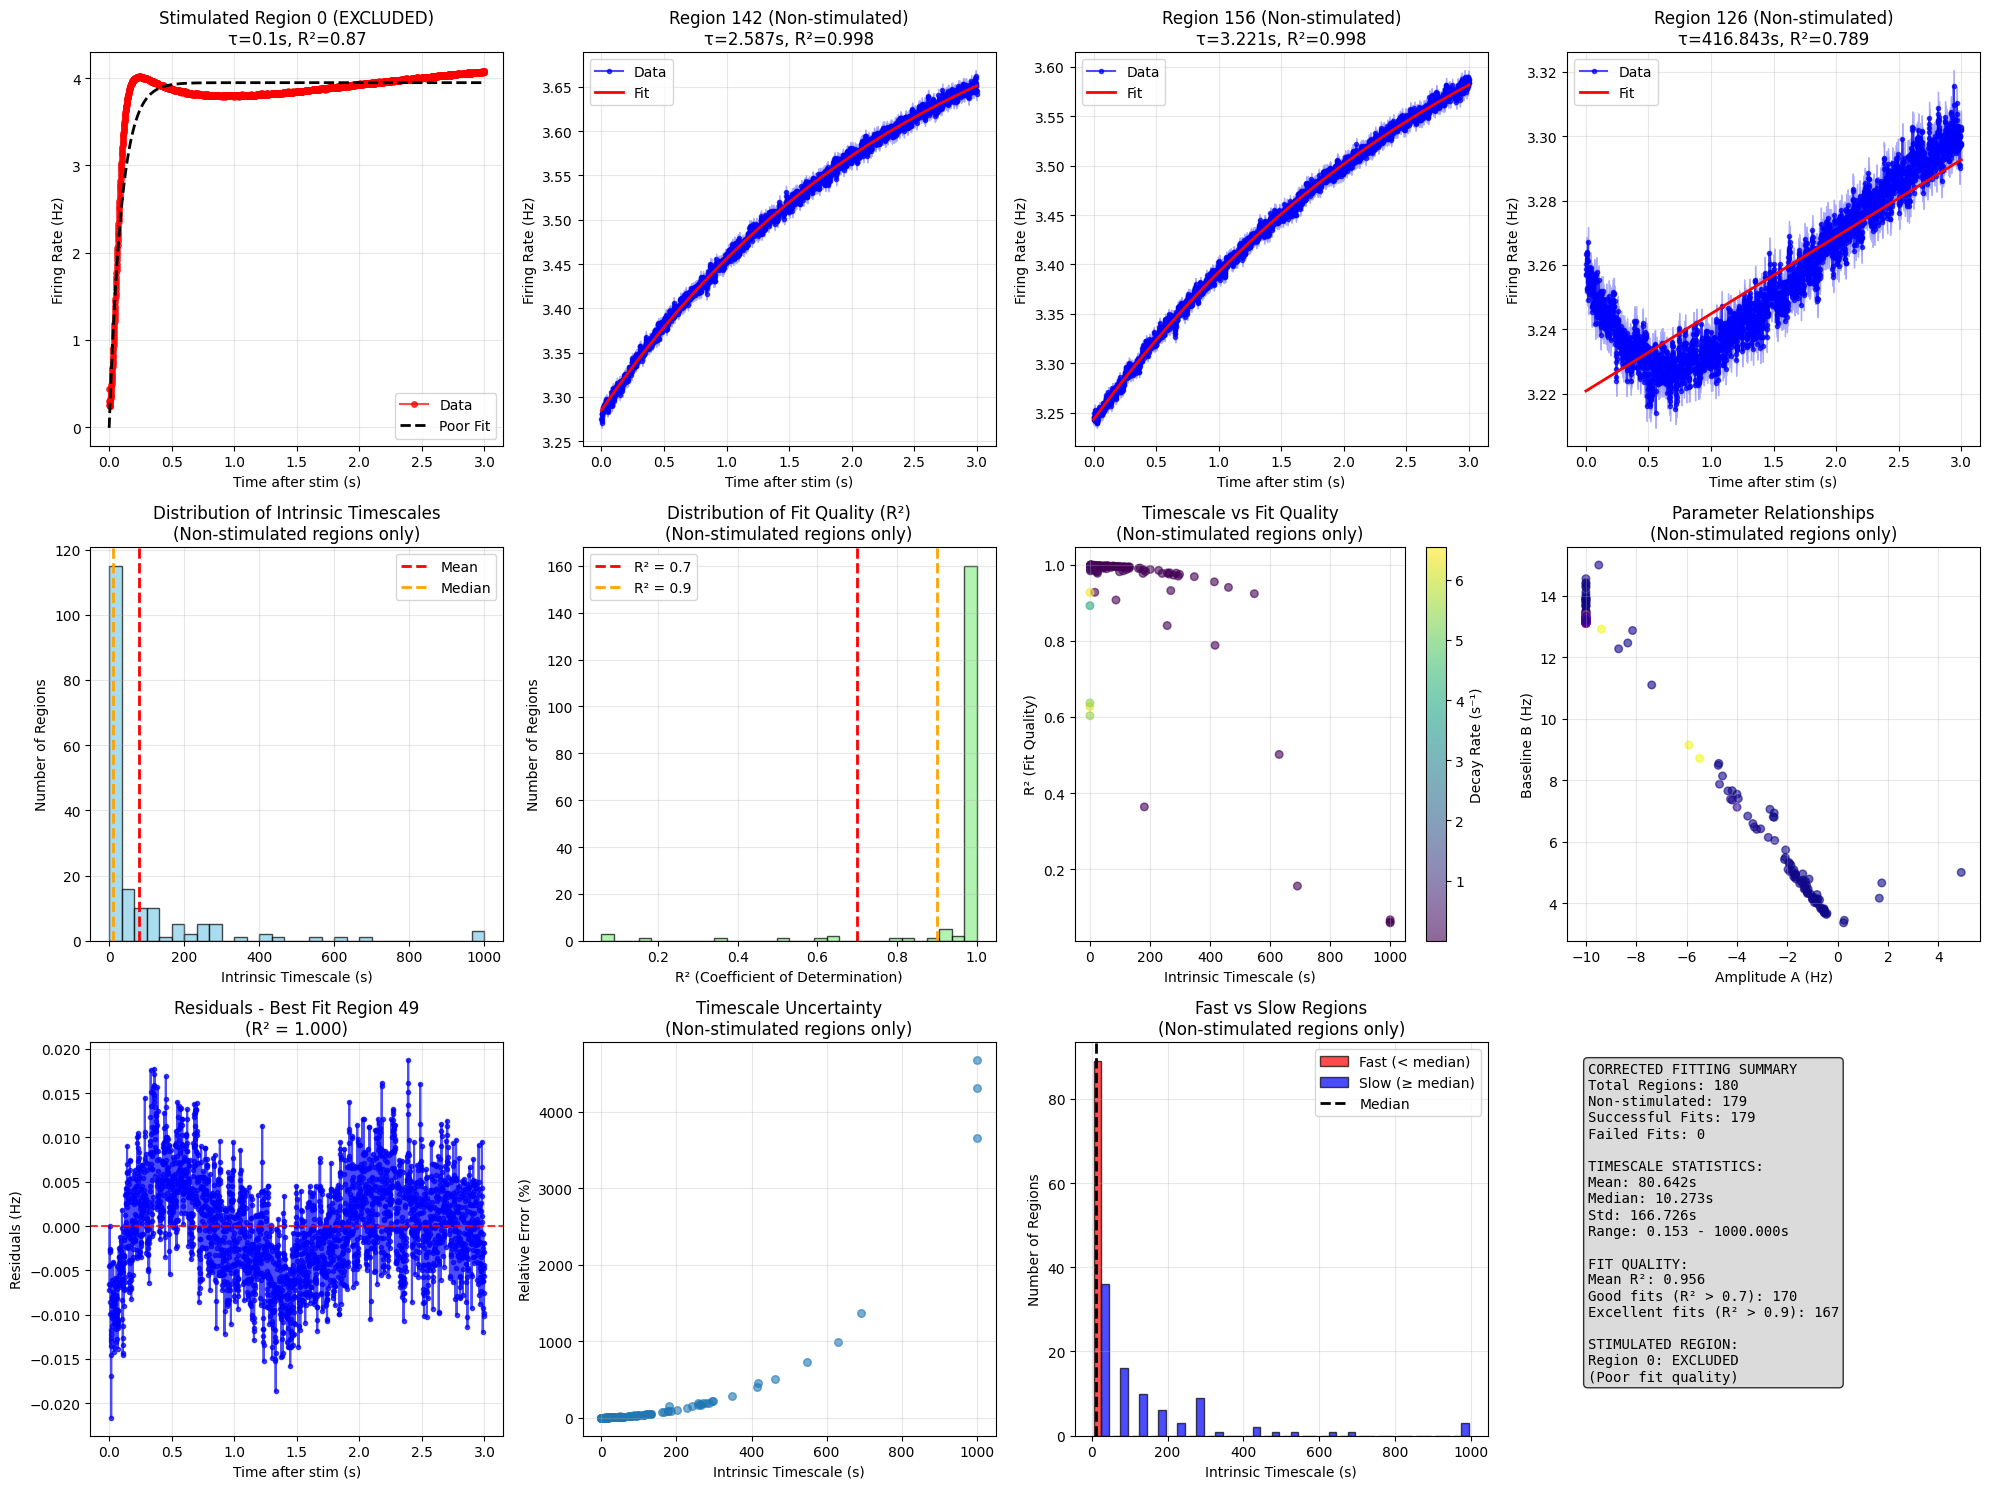


✓ Corrected visualization completed!


In [10]:
# Corrected Visualization: Exclude stimulated region from main plots
print("=== CORRECTED VISUALIZATION (EXCLUDING STIMULATED REGION) ===")

import matplotlib.pyplot as plt
import numpy as np

if corrected_summary['n_successful_non_stim'] > 0:
    # Create comprehensive figure
    fig = plt.figure(figsize=(20, 15))
    
    # 1. Stimulated region (shown separately for reference)
    ax1 = plt.subplot(3, 4, 1)
    stim_idx = decay_data['stimulated_region']
    if fitting_results[stim_idx]['success']:
        result = fitting_results[stim_idx]
        ax1.plot(t_fit, decay_data['r_E_decay'][stim_idx, :], 'ro-', markersize=4, alpha=0.7, label='Data')
        ax1.plot(t_fit, result['fitted_values'], 'k--', linewidth=2, label='Poor Fit')
        ax1.fill_between(t_fit, 
                        decay_data['r_E_decay'][stim_idx, :] - decay_data['sem_decay'][stim_idx, :],
                        decay_data['r_E_decay'][stim_idx, :] + decay_data['sem_decay'][stim_idx, :],
                        alpha=0.3, color='red')
        ax1.set_title(f'Stimulated Region {stim_idx} (EXCLUDED)\nτ={result["timescale"]:.1f}s, R²={result["r_squared"]:.2f}')
    else:
        ax1.text(0.5, 0.5, 'Fit Failed', transform=ax1.transAxes, ha='center', va='center', color='red')
        ax1.set_title(f'Stimulated Region {stim_idx} - FAILED (EXCLUDED)')
    ax1.set_xlabel('Time after stim (s)')
    ax1.set_ylabel('Firing Rate (Hz)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2-4. Sample successful fits from NON-STIMULATED regions
    non_stim_successful = [i for i in corrected_summary['non_stim_indices'] if fitting_results[i]['success']]
    sample_indices = np.random.choice(non_stim_successful, min(3, len(non_stim_successful)), replace=False)
    
    for i, idx in enumerate(sample_indices):
        ax = plt.subplot(3, 4, 2 + i)
        result = fitting_results[idx]
        ax.plot(t_fit, decay_data['r_E_decay'][idx, :], 'bo-', markersize=3, alpha=0.7, label='Data')
        ax.plot(t_fit, result['fitted_values'], 'r-', linewidth=2, label='Fit')
        ax.fill_between(t_fit,
                       decay_data['r_E_decay'][idx, :] - decay_data['sem_decay'][idx, :],
                       decay_data['r_E_decay'][idx, :] + decay_data['sem_decay'][idx, :],
                       alpha=0.3, color='blue')
        ax.set_title(f'Region {idx} (Non-stimulated)\nτ={result["timescale"]:.3f}s, R²={result["r_squared"]:.3f}')
        ax.set_xlabel('Time after stim (s)')
        ax.set_ylabel('Firing Rate (Hz)')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    # 5. Distribution of intrinsic timescales (NON-STIMULATED ONLY)
    ax5 = plt.subplot(3, 4, 5)
    ax5.hist(corrected_summary['timescales'], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    ax5.axvline(np.mean(corrected_summary['timescales']), color='red', linestyle='--', linewidth=2, label='Mean')
    ax5.axvline(np.median(corrected_summary['timescales']), color='orange', linestyle='--', linewidth=2, label='Median')
    ax5.set_xlabel('Intrinsic Timescale (s)')
    ax5.set_ylabel('Number of Regions')
    ax5.set_title('Distribution of Intrinsic Timescales\n(Non-stimulated regions only)')
    ax5.legend()
    ax5.grid(True, alpha=0.3)
    
    # 6. Distribution of R² values (NON-STIMULATED ONLY)
    ax6 = plt.subplot(3, 4, 6)
    ax6.hist(corrected_summary['r_squared_values'], bins=30, alpha=0.7, color='lightgreen', edgecolor='black')
    ax6.axvline(0.7, color='red', linestyle='--', linewidth=2, label='R² = 0.7')
    ax6.axvline(0.9, color='orange', linestyle='--', linewidth=2, label='R² = 0.9')
    ax6.set_xlabel('R² (Coefficient of Determination)')
    ax6.set_ylabel('Number of Regions')
    ax6.set_title('Distribution of Fit Quality (R²)\n(Non-stimulated regions only)')
    ax6.legend()
    ax6.grid(True, alpha=0.3)
    
    # 7. Timescale vs Fit Quality (NON-STIMULATED ONLY)
    ax7 = plt.subplot(3, 4, 7)
    scatter = ax7.scatter(corrected_summary['timescales'], corrected_summary['r_squared_values'], 
                         c=corrected_summary['decay_rates'], cmap='viridis', alpha=0.6, s=30)
    ax7.set_xlabel('Intrinsic Timescale (s)')
    ax7.set_ylabel('R² (Fit Quality)')
    ax7.set_title('Timescale vs Fit Quality\n(Non-stimulated regions only)')
    ax7.grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=ax7, label='Decay Rate (s⁻¹)')
    
    # 8. Parameter correlations (NON-STIMULATED ONLY)
    ax8 = plt.subplot(3, 4, 8)
    ax8.scatter(corrected_summary['amplitudes'], corrected_summary['baselines'], 
               c=corrected_summary['timescales'], cmap='plasma', alpha=0.6, s=30)
    ax8.set_xlabel('Amplitude A (Hz)')
    ax8.set_ylabel('Baseline B (Hz)')
    ax8.set_title('Parameter Relationships\n(Non-stimulated regions only)')
    ax8.grid(True, alpha=0.3)
    
    # 9. Residual analysis for best non-stimulated region
    ax9 = plt.subplot(3, 4, 9)
    best_non_stim_idx_local = np.argmax(corrected_summary['r_squared_values'])
    best_non_stim_region = corrected_summary['non_stim_indices'][best_non_stim_idx_local]
    best_result = fitting_results[best_non_stim_region]
    
    residuals = best_result['residuals']
    ax9.plot(t_fit, residuals, 'bo-', markersize=3, alpha=0.7)
    ax9.axhline(0, color='red', linestyle='--', alpha=0.8)
    ax9.set_xlabel('Time after stim (s)')
    ax9.set_ylabel('Residuals (Hz)')
    ax9.set_title(f'Residuals - Best Fit Region {best_non_stim_region}\n(R² = {best_result["r_squared"]:.3f})')
    ax9.grid(True, alpha=0.3)
    
    # 10. Timescale uncertainty analysis (NON-STIMULATED ONLY)
    ax10 = plt.subplot(3, 4, 10)
    relative_errors = corrected_summary['timescale_errors'] / corrected_summary['timescales'] * 100
    ax10.scatter(corrected_summary['timescales'], relative_errors, alpha=0.6, s=30)
    ax10.set_xlabel('Intrinsic Timescale (s)')
    ax10.set_ylabel('Relative Error (%)')
    ax10.set_title('Timescale Uncertainty\n(Non-stimulated regions only)')
    ax10.grid(True, alpha=0.3)
    
    # 11. Fast vs Slow regions (NON-STIMULATED ONLY)
    ax11 = plt.subplot(3, 4, 11)
    tau_median = np.median(corrected_summary['timescales'])
    fast_mask = corrected_summary['timescales'] < tau_median
    slow_mask = corrected_summary['timescales'] >= tau_median
    
    ax11.hist([corrected_summary['timescales'][fast_mask], corrected_summary['timescales'][slow_mask]], 
             bins=20, alpha=0.7, label=['Fast (< median)', 'Slow (≥ median)'], 
             color=['red', 'blue'], edgecolor='black')
    ax11.axvline(tau_median, color='black', linestyle='--', linewidth=2, label='Median')
    ax11.set_xlabel('Intrinsic Timescale (s)')
    ax11.set_ylabel('Number of Regions')
    ax11.set_title('Fast vs Slow Regions\n(Non-stimulated regions only)')
    ax11.legend()
    ax11.grid(True, alpha=0.3)
    
    # 12. Corrected summary statistics
    ax12 = plt.subplot(3, 4, 12)
    ax12.axis('off')
    
    # Create corrected summary text
    summary_text = "CORRECTED FITTING SUMMARY\n"
    summary_text += f"Total Regions: {n_regions}\n"
    summary_text += f"Non-stimulated: {corrected_summary['n_successful_non_stim'] + corrected_summary['n_failed_non_stim']}\n"
    summary_text += f"Successful Fits: {corrected_summary['n_successful_non_stim']}\n"
    summary_text += f"Failed Fits: {corrected_summary['n_failed_non_stim']}\n\n"
    summary_text += "TIMESCALE STATISTICS:\n"
    summary_text += f"Mean: {corrected_summary['timescales'].mean():.3f}s\n"
    summary_text += f"Median: {np.median(corrected_summary['timescales']):.3f}s\n"
    summary_text += f"Std: {corrected_summary['timescales'].std():.3f}s\n"
    summary_text += f"Range: {corrected_summary['timescales'].min():.3f} - {corrected_summary['timescales'].max():.3f}s\n\n"
    summary_text += "FIT QUALITY:\n"
    summary_text += f"Mean R²: {corrected_summary['r_squared_values'].mean():.3f}\n"
    summary_text += f"Good fits (R² > 0.7): {np.sum(corrected_summary['r_squared_values'] > 0.7)}\n"
    summary_text += f"Excellent fits (R² > 0.9): {np.sum(corrected_summary['r_squared_values'] > 0.9)}\n\n"
    summary_text += "STIMULATED REGION:\n"
    summary_text += f"Region {stim_idx}: EXCLUDED\n"
    summary_text += "(Poor fit quality)"
    
    ax12.text(0.05, 0.95, summary_text, transform=ax12.transAxes, fontsize=10,
             verticalalignment='top', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))
    
    plt.tight_layout()
    plt.show()
    
else:
    print("Error: No successful fits for non-stimulated regions to visualize.")

print(f"\n✓ Corrected visualization completed!")


In [11]:
# ==========================================
# DATA SAVING - HDF FORMAT
# ==========================================

import h5py
import json
from datetime import datetime
import os

def save_int_results(model_config, config, model_params, model_type, latest_iter, 
                    fitting_results, corrected_summary, decay_data):
    """Save intrinsic timescale results to HDF5 format with dynamic filename."""
    
    # Create results directory
    results_dir = os.path.join(data.output_dir, "INT_Results")
    os.makedirs(results_dir, exist_ok=True)
    
    # Generate dynamic filename from configuration
    timestamp = datetime.now().strftime("%Y%m%d_%H%M")
    
    filename = f"INT_{model_config['model_folder']}_{model_type}_iter{latest_iter}_{timestamp}.hdf5"
    filepath = os.path.join(results_dir, filename)
    
    print(f"💾 Saving intrinsic timescale results...")
    print(f"   File: {filename}")
    print(f"   Path: {filepath}")
    
    with h5py.File(filepath, 'w') as f:
        # ==========================================
        # METADATA GROUP
        # ==========================================
        meta_grp = f.create_group('metadata')
        
        # Model configuration
        meta_grp.attrs['model_folder'] = model_config['model_folder']
        meta_grp.attrs['model_type'] = model_type
        meta_grp.attrs['iteration'] = latest_iter
        meta_grp.attrs['n_params'] = len(model_params)
        meta_grp.attrs['timestamp'] = timestamp
        
        # Stimulation configuration
        stim_grp = meta_grp.create_group('stimulation_config')
        for key, value in config.items():
            stim_grp.attrs[key] = value
            
        # Model parameters
        param_grp = meta_grp.create_group('model_parameters')
        if model_type == "homogeneous":
            param_grp.attrs['w_EI'] = model_params['w_EI']
            param_grp.attrs['w_EE'] = model_params['w_EE']
            param_grp.attrs['G'] = model_params['G']
        elif model_type == "heterogeneous":
            param_grp.create_dataset('w_EI', data=np.array(model_params['w_EI']))
            param_grp.create_dataset('w_EE', data=np.array(model_params['w_EE']))
            param_grp.attrs['G'] = model_params['G']
        
        # Map configuration (if heterogeneous)
        if model_type == "heterogeneous":
            map_grp = meta_grp.create_group('map_config')
            map_config = model_config.get('map_config', {})
            
            # Save map configuration with safe key access
            map_grp.attrs['use_default_map'] = map_config.get('use_default_map', True)
            if 'map_type' in map_config:
                map_grp.attrs['map_type'] = map_config['map_type']
            if map_config.get('custom_map_path') is not None:
                map_grp.attrs['custom_map_path'] = map_config['custom_map_path']
            if 'invert_flags' in map_config:
                map_grp.create_dataset('invert_flags', data=np.array(map_config['invert_flags']))
        
        # ==========================================
        # RAW DATA GROUP
        # ==========================================
        raw_grp = f.create_group('raw_data')
        
        # Time series data
        raw_grp.create_dataset('time_points', data=decay_data['time_points'])
        raw_grp.create_dataset('time_decay_rel', data=decay_data['time_decay_rel'])
        raw_grp.create_dataset('mean_r_E_full', data=decay_data['mean_r_E_full'])
        raw_grp.create_dataset('sem_r_E_full', data=decay_data['sem_r_E_full'])
        raw_grp.create_dataset('r_E_decay', data=decay_data['r_E_decay'])
        raw_grp.create_dataset('sem_decay', data=decay_data['sem_decay'])
        
        # Regional characteristics
        raw_grp.create_dataset('baseline_r_E', data=decay_data['baseline_r_E'])
        raw_grp.create_dataset('peak_r_E', data=decay_data['peak_r_E'])
        raw_grp.create_dataset('initial_post_r_E', data=decay_data['initial_post_r_E'])
        raw_grp.create_dataset('final_post_r_E', data=decay_data['final_post_r_E'])
        
        # Simulation info
        raw_grp.attrs['n_trials'] = decay_data['n_trials']
        raw_grp.attrs['n_regions'] = decay_data['n_regions']
        raw_grp.attrs['stimulated_region'] = decay_data['stimulated_region']
        
        # ==========================================
        # FITTING RESULTS GROUP
        # ==========================================
        fit_grp = f.create_group('fitting_results')
        
        # Individual region results
        regions_grp = fit_grp.create_group('regions')
        for i, result in enumerate(fitting_results):
            region_grp = regions_grp.create_group(f'region_{i:03d}')
            
            # Store all scalar results as attributes
            for key, value in result.items():
                if isinstance(value, (int, float, bool, str)) and not np.isnan(value) if isinstance(value, float) else True:
                    region_grp.attrs[key] = value
                elif isinstance(value, np.ndarray):
                    region_grp.create_dataset(key, data=value)
        
        # Summary statistics (all regions)
        summary_grp = fit_grp.create_group('summary_all_regions')
        fit_summary_keys = ['n_successful', 'n_failed', 'timescales', 'timescale_errors', 
                           'r_squared_values', 'decay_rates', 'amplitudes', 'baselines']
        
        # Note: This would need fit_summary to be defined. Let me create it from fitting_results
        n_successful = sum(1 for r in fitting_results if r['success'])
        n_failed = len(fitting_results) - n_successful
        
        summary_grp.attrs['n_successful'] = n_successful
        summary_grp.attrs['n_failed'] = n_failed
        
        # Extract arrays for successful fits
        successful_results = [r for r in fitting_results if r['success']]
        if successful_results:
            summary_grp.create_dataset('timescales', data=np.array([r['timescale'] for r in successful_results]))
            summary_grp.create_dataset('timescale_errors', data=np.array([r['timescale_err'] for r in successful_results]))
            summary_grp.create_dataset('r_squared_values', data=np.array([r['r_squared'] for r in successful_results]))
            summary_grp.create_dataset('decay_rates', data=np.array([r['D'] for r in successful_results]))
            summary_grp.create_dataset('amplitudes', data=np.array([r['A'] for r in successful_results]))
            summary_grp.create_dataset('baselines', data=np.array([r['B'] for r in successful_results]))
            summary_grp.create_dataset('successful_region_indices', data=np.array([i for i, r in enumerate(fitting_results) if r['success']]))
        
        # ==========================================
        # CORRECTED RESULTS GROUP (excluding stimulated region)
        # ==========================================
        if 'corrected_summary' in locals():
            corr_grp = f.create_group('corrected_results')
            
            # Summary statistics
            for key, value in corrected_summary.items():
                if isinstance(value, (int, float)):
                    corr_grp.attrs[key] = value
                elif isinstance(value, np.ndarray):
                    corr_grp.create_dataset(key, data=value)
                elif isinstance(value, list) and len(value) > 0:
                    corr_grp.create_dataset(key, data=np.array(value))
    
    # ==========================================
    # SAVE COMPLETION SUMMARY
    # ==========================================
    
    file_size_mb = os.path.getsize(filepath) / (1024 * 1024)
    
    print(f"✅ Results saved successfully!")
    print(f"   File size: {file_size_mb:.2f} MB")
    print(f"   Regions processed: {len(fitting_results)}")
    print(f"   Successful fits: {n_successful}/{len(fitting_results)} ({100*n_successful/len(fitting_results):.1f}%)")
    
    return filepath

# ==========================================
# EXECUTE SAVE OPERATION
# ==========================================

# Save the results
saved_filepath = save_int_results(
    model_config=MODEL_CONFIG,
    config=CONFIG, 
    model_params=model_params,
    model_type=model_type,
    latest_iter=latest_iter,
    fitting_results=fitting_results,
    corrected_summary=corrected_summary if 'corrected_summary' in locals() else None,
    decay_data=decay_data
)

print(f"\n📁 Results location: {saved_filepath}")
print(f"🔗 To load results later:")
print(f"   import h5py")
print(f"   with h5py.File('{saved_filepath}', 'r') as f:")
print(f"       # Access data: f['group_name/dataset_name'][:]")
print(f"       # Access metadata: f['group_name'].attrs['attr_name']")

💾 Saving intrinsic timescale results...
   File: INT_NMDA_AVG_heterogeneous_iter41_20250816_2053.hdf5
   Path: /home/frank/HBNM/outputs/INT_Results/INT_NMDA_AVG_heterogeneous_iter41_20250816_2053.hdf5
✅ Results saved successfully!
   File size: 36.21 MB
   Regions processed: 180
   Successful fits: 180/180 (100.0%)

📁 Results location: /home/frank/HBNM/outputs/INT_Results/INT_NMDA_AVG_heterogeneous_iter41_20250816_2053.hdf5
🔗 To load results later:
   import h5py
   with h5py.File('/home/frank/HBNM/outputs/INT_Results/INT_NMDA_AVG_heterogeneous_iter41_20250816_2053.hdf5', 'r') as f:
       # Access data: f['group_name/dataset_name'][:]
       # Access metadata: f['group_name'].attrs['attr_name']
